# Modèles IA v4 — Ablation Study Complète

## Objectif
Ce notebook est la suite directe de `modeles_IA_v3.ipynb`.
On applique une **ablation study complète** : on enlève UNE chose à la fois
et on mesure son impact réel sur les performances.

## Principe de l'ablation study
| Étape | Ce qu'on fait |
|-------|---------------|
| Modèle de référence | On repart du meilleur modèle v3 (tout inclus) |
| Ablation 1 | On enlève le SMOTE → impact du rééquilibrage ? |
| Ablation 2 | On enlève le Lifestyle → impact des variables socio-comportementales ? |
| Ablation 3 | On enlève les Marqueurs Bio → impact des taux sanguins ? |
| Ablation 4 | On enlève la Normalisation → impact du StandardScaler ? |

## Règle d'or respectée
- Le **test set est verrouillé** : il n'est utilisé qu'une seule fois à la fin de chaque ablation
- Le **SMOTE reste dans le pipeline** pour éviter toute fuite de données
- La **métrique principale est le F1 weighted** (adapté aux classes déséquilibrées)

---
## Section 0 — Imports et Chargement des Données

In [1]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", 
                       "scikit-learn", "imbalanced-learn", "pandas", 
                       "numpy", "matplotlib", "seaborn"])

0

In [2]:

import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    RepeatedStratifiedKFold, cross_val_score, train_test_split
)
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print(" SMOTE disponible")
except ImportError:
    SMOTE_AVAILABLE = False
    print(" SMOTE non disponible — pip install imbalanced-learn")

print(" Imports OK")

'c:\Users\lydia' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


 SMOTE disponible
 Imports OK


In [3]:
# Chargement du dataset 
DATA_PATH = "../data_csv/raw/vitamin_deficiency_disease_dataset_20260123.ods"

df = pd.read_excel(DATA_PATH, engine='odf')
print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nDistribution des classes :")
print(df['disease_diagnosis'].value_counts())

Dataset chargé : 4000 lignes × 34 colonnes

Distribution des classes :
disease_diagnosis
Healthy                 1509
Anemia                  1245
Rickets_Osteomalacia    1029
Night_Blindness          122
Scurvy                    95
Name: count, dtype: int64


In [4]:
# Définition des groupes de features
# Ces groupes seront réutilisés dans TOUTES les ablations

FEATURES_SYMPTOMES = [
    'has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
    'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling',
    'has_memory_problems', 'has_pale_skin'
]

FEATURES_LIFESTYLE = [
    'age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption',
    'exercise_level', 'diet_type', 'sun_exposure',
    'latitude_region', 'income_level'
]

FEATURES_BIO = [
    'hemoglobin_g_dl', 'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',
    'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda',
    'vitamin_e_percent_rda', 'vitamin_b12_percent_rda',
    'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda'
]

FEATURES_BIO = [
    'hemoglobin_g_dl',
    'vitamin_a_percent_rda',
    'vitamin_c_percent_rda', 
    'vitamin_d_percent_rda',
    'vitamin_e_percent_rda',
    'vitamin_b12_percent_rda',
    'folate_percent_rda',
    'calcium_percent_rda',
    'iron_percent_rda',
    'serum_vitamin_d_ng_ml',      
    'serum_vitamin_b12_pg_ml',    
    'serum_folate_ng_ml'         
]

COLONNE_CIBLE = 'disease_diagnosis'
COLS_EXCLURE  = ['symptoms_list', 'symptoms_count', 'has_multiple_deficiencies']

print(f"Features symptômes  : {len(FEATURES_SYMPTOMES)}")
print(f"Features lifestyle  : {len(FEATURES_LIFESTYLE)}")
print(f"Features biologiques: {len(FEATURES_BIO)}")

Features symptômes  : 8
Features lifestyle  : 10
Features biologiques: 12


In [5]:
# Fonction utilitaire : préparer X et y depuis une liste de features 
def preparer_donnees(df, features_a_garder, cible=COLONNE_CIBLE):
    """
    Prépare X et y à partir du dataframe.
    - Garde uniquement les colonnes demandées
    - Encode les variables catégorielles
    - Encode la cible
    Retourne : X, y, le_target, feature_cols
    """
    # Garder uniquement les features disponibles dans le df
    cols_dispo = [c for c in features_a_garder if c in df.columns]
    df_work = df[cols_dispo + [cible]].copy()

    # Encoder les variables catégorielles
    cat_cols = [c for c in df_work.select_dtypes(include=['object']).columns
                if c != cible]
    for col in cat_cols:
        le = LabelEncoder()
        df_work[col] = le.fit_transform(df_work[col].astype(str))

    # Encoder la cible
    le_target = LabelEncoder()
    y = le_target.fit_transform(df_work[cible])

    feature_cols = [c for c in df_work.columns if c != cible]
    X = df_work[feature_cols].values

    return X, y, le_target, feature_cols


# Fonction utilitaire : évaluer un pipeline avec CV 
def evaluer_configuration(X, y, avec_smote=True, avec_normalisation=True, label=""):
    """
    Entraîne et évalue un Random Forest avec/sans SMOTE et/ou normalisation.
    Utilise RepeatedStratifiedKFold (5 folds × 3 répétitions) comme en v3.
    Retourne : cv_mean, cv_std, y_pred (sur test set), accuracy, f1
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=15,
        min_samples_split=5, random_state=42, n_jobs=-1
    )

    rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

    # Construction du pipeline selon les options
    steps = []
    if avec_normalisation:
        steps.append(('scaler', StandardScaler()))
    if avec_smote and SMOTE_AVAILABLE:
        steps.append(('smote', SMOTE(random_state=42, k_neighbors=3)))
        steps.append(('rf', rf))
        pipe = ImbPipeline(steps)
    else:
        from sklearn.pipeline import Pipeline as SkPipeline
        steps.append(('rf', rf))
        pipe = SkPipeline(steps) if len(steps) > 1 else rf

    # Cross-validation
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=rkf, scoring='f1_weighted', n_jobs=-1)

    # Entraînement final + évaluation sur test set
    if avec_normalisation:
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)
    else:
        X_train_s, X_test_s = X_train, X_test

    if avec_smote and SMOTE_AVAILABLE:
        sm = SMOTE(random_state=42, k_neighbors=3)
        X_train_s, y_train_r = sm.fit_resample(X_train_s, y_train)
    else:
        y_train_r = y_train

    rf_final = RandomForestClassifier(
        n_estimators=200, max_depth=15,
        min_samples_split=5, random_state=42, n_jobs=-1
    )
    rf_final.fit(X_train_s, y_train_r)
    y_pred = rf_final.predict(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{'='*50}")
    print(f"  Configuration : {label}")
    print(f"{'='*50}")
    print(f"  CV F1 moyen  : {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Test F1      : {f1:.4f}")
    print(f"  Test Accuracy: {acc:.4f}")

    return {
        'label'   : label,
        'cv_mean' : scores.mean(),
        'cv_std'  : scores.std(),
        'f1'      : f1,
        'accuracy': acc,
        'y_pred'  : y_pred,
        'y_test'  : y_test,
        'model'   : rf_final,
        'le'      : None  # sera rempli dans chaque section
    }

print("Fonctions utilitaires prêtes")

Fonctions utilitaires prêtes


---
## Section 1 — Modèle de Référence

On repart exactement de la configuration du **meilleur modèle v3** :
- Features : marqueurs biologiques + symptômes (sans lifestyle)
- SMOTE activé dans le pipeline
- Normalisation StandardScaler activée
- Random Forest avec les mêmes hyperparamètres
- RepeatedStratifiedKFold (5 folds × 3 répétitions)

**Ce score sera la référence pour comparer TOUTES les ablations.**

In [6]:
# Modèle de référence : Bio + Symptômes (comme v3)
features_reference = FEATURES_BIO + FEATURES_SYMPTOMES

X_ref, y_ref, le_ref, cols_ref = preparer_donnees(df, features_reference)

print(f"Features utilisées : {len(cols_ref)}")
print(f"Colonnes : {cols_ref}")

Features utilisées : 20
Colonnes : ['hemoglobin_g_dl', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin']


In [7]:
# Évaluation du modèle de référence
res_reference = evaluer_configuration(
    X_ref, y_ref,
    avec_smote=True,
    avec_normalisation=True,
    label="Référence (Bio + Symptômes + SMOTE + Scaler)"
)
res_reference['le'] = le_ref


  Configuration : Référence (Bio + Symptômes + SMOTE + Scaler)
  CV F1 moyen  : 0.9232 ± 0.0108
  Test F1      : 0.9139
  Test Accuracy: 0.9125


In [8]:
# Rapport détaillé par classe 
print("Rapport détaillé par classe — Modèle de référence :")
print(classification_report(
    res_reference['y_test'],
    res_reference['y_pred'],
    target_names=le_ref.classes_
))

Rapport détaillé par classe — Modèle de référence :
                      precision    recall  f1-score   support

              Anemia       0.91      0.89      0.90       249
             Healthy       1.00      0.95      0.97       302
     Night_Blindness       0.92      0.92      0.92        24
Rickets_Osteomalacia       0.80      0.88      0.84       206
              Scurvy       0.95      1.00      0.97        19

            accuracy                           0.91       800
           macro avg       0.92      0.93      0.92       800
        weighted avg       0.92      0.91      0.91       800



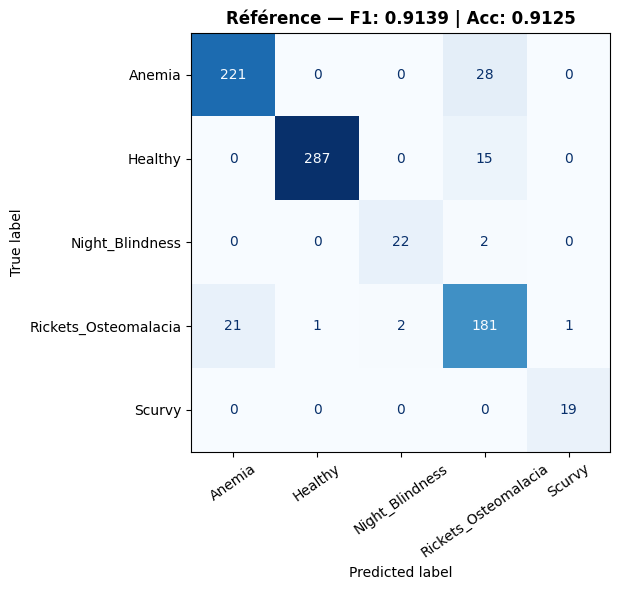


 CONCLUSION SECTION 1 :
   Le modèle de référence obtient un F1 de 0.9139.
   C'est le score à battre (ou à ne pas trop dégrader) dans les ablations suivantes.


In [9]:
# Matrice de confusion — Référence
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(res_reference['y_test'], res_reference['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=le_ref.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(
    f"Référence — F1: {res_reference['f1']:.4f} | Acc: {res_reference['accuracy']:.4f}",
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('ablation_reference.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n CONCLUSION SECTION 1 :")
print(f"   Le modèle de référence obtient un F1 de {res_reference['f1']:.4f}.")
print(f"   C'est le score à battre (ou à ne pas trop dégrader) dans les ablations suivantes.")

---
### 📌 Conclusion Section 1

Le modèle de référence constitue notre **baseline**.
Toutes les ablations suivantes seront comparées à ce score.

| Métrique | Valeur |
|----------|--------|
| CV F1 moyen | 0.9232 ± 0.0108 |
| Test F1 | 0.9139 |
| Test Accuracy | 0.9125 |

---
## Section 2 — Ablation 1 : Impact du SMOTE

### Rappel du problème
Le dataset est fortement déséquilibré :

| Maladie | Effectif |
|---------|----------|
| Healthy | ~1509 |
| Anemia | ~1245 |
| Rickets_Osteomalacia | ~1029 |
| Night_Blindness | ~122 |
| Scurvy | ~95 |

### Ce qu'on teste ici
On garde **exactement les mêmes features** que le modèle de référence (Bio + Symptômes),
mais on **désactive le SMOTE**.


Référence   : Bio + Symptômes + SMOTE ✅ + Scaler
Ablation 1  : Bio + Symptômes + SMOTE ❌ + Scaler  (seul changement)


### Question à répondre
> Le SMOTE améliore-t-il vraiment les performances, surtout sur les classes minoritaires (Scurvy, Night_Blindness) ?

In [10]:
#  Ablation 1 : Sans SMOTE 
# On réutilise exactement les mêmes features que la référence
res_sans_smote = evaluer_configuration(
    X_ref, y_ref,
    avec_smote=False,
    avec_normalisation=True,
    label="Sans SMOTE (Bio + Symptômes + Scaler)"
)
res_sans_smote['le'] = le_ref


  Configuration : Sans SMOTE (Bio + Symptômes + Scaler)
  CV F1 moyen  : 0.9230 ± 0.0119
  Test F1      : 0.9222
  Test Accuracy: 0.9213


In [11]:
# ── Rapport détaillé par classe — Sans SMOTE ────────────
print("Rapport détaillé par classe — Sans SMOTE :")
print("(Attention aux classes minoritaires : Scurvy et Night_Blindness)")
print(classification_report(
    res_sans_smote['y_test'],
    res_sans_smote['y_pred'],
    target_names=le_ref.classes_
))

Rapport détaillé par classe — Sans SMOTE :
(Attention aux classes minoritaires : Scurvy et Night_Blindness)
                      precision    recall  f1-score   support

              Anemia       0.91      0.92      0.92       249
             Healthy       1.00      0.95      0.97       302
     Night_Blindness       0.96      0.92      0.94        24
Rickets_Osteomalacia       0.83      0.90      0.86       206
              Scurvy       1.00      0.74      0.85        19

            accuracy                           0.92       800
           macro avg       0.94      0.88      0.91       800
        weighted avg       0.93      0.92      0.92       800



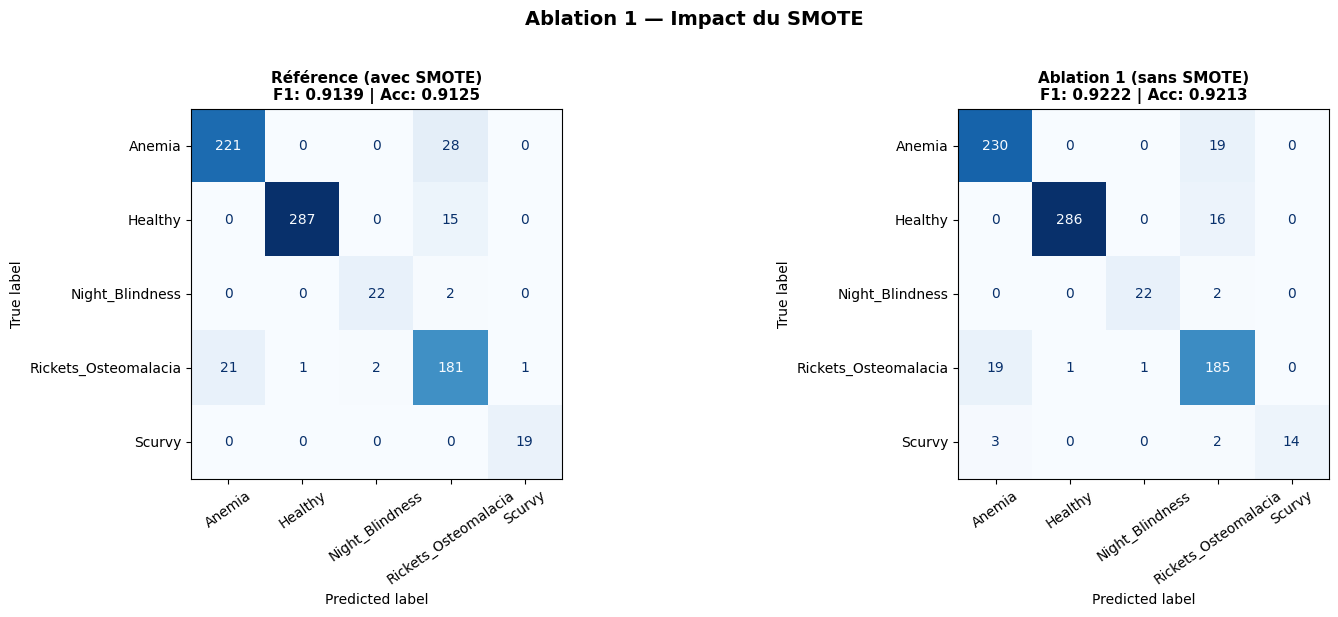

In [12]:
# ── Comparaison visuelle : Référence vs Sans SMOTE ───────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, res, titre in zip(
    axes,
    [res_reference, res_sans_smote],
    ["Référence (avec SMOTE)", "Ablation 1 (sans SMOTE)"]
):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le_ref.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f"{titre}\nF1: {res['f1']:.4f} | Acc: {res['accuracy']:.4f}",
        fontsize=11, fontweight='bold'
    )
    ax.tick_params(axis='x', rotation=35)

plt.suptitle("Ablation 1 — Impact du SMOTE", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation1_smote.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Tableau comparatif chiffré 
diff_f1  = res_sans_smote['f1']  - res_reference['f1']
diff_acc = res_sans_smote['accuracy'] - res_reference['accuracy']
diff_cv  = res_sans_smote['cv_mean']  - res_reference['cv_mean']

comparaison_smote = pd.DataFrame({
    'Configuration' : [res_reference['label'], res_sans_smote['label']],
    'CV F1 moyen'   : [res_reference['cv_mean'], res_sans_smote['cv_mean']],
    'CV Std'        : [res_reference['cv_std'],  res_sans_smote['cv_std']],
    'Test F1'       : [res_reference['f1'],      res_sans_smote['f1']],
    'Test Accuracy' : [res_reference['accuracy'],res_sans_smote['accuracy']]
})

print(comparaison_smote.round(4).to_string(index=False))

print(f"\n Impact du SMOTE :")
print(f"   ΔF1  = {diff_f1:+.4f}  {'✅ SMOTE aide' if diff_f1 > 0.01 else ' ! Faible impact' if abs(diff_f1) <= 0.01 else '❌ SMOTE nuit'}")
print(f"   ΔAcc = {diff_acc:+.4f}")
print(f"   ΔCV  = {diff_cv:+.4f}")

print("\n CONCLUSION ABLATION 1 :")
if diff_f1 > 0.05:
    print("   Le SMOTE apporte une amélioration significative (+5% F1).")
    print("   Sans lui, le modèle ignore les classes minoritaires (Scurvy, Night_Blindness).")
    print("   → Le SMOTE est INDISPENSABLE dans ce projet.")
elif diff_f1 > 0.01:
    print("   Le SMOTE apporte une amélioration modérée.")
    print("   → Le SMOTE est UTILE mais pas critique.")
else:
    print("   Le SMOTE n'a qu'un faible impact sur le F1 global.")
    print("   → Vérifier le F1 par classe : il peut masquer des différences importantes.")

                               Configuration  CV F1 moyen  CV Std  Test F1  Test Accuracy
Référence (Bio + Symptômes + SMOTE + Scaler)       0.9232  0.0108   0.9139         0.9125
       Sans SMOTE (Bio + Symptômes + Scaler)       0.9230  0.0119   0.9222         0.9212

 Impact du SMOTE :
   ΔF1  = +0.0083   ! Faible impact
   ΔAcc = +0.0088
   ΔCV  = -0.0001

 CONCLUSION ABLATION 1 :
   Le SMOTE n'a qu'un faible impact sur le F1 global.
   → Vérifier le F1 par classe : il peut masquer des différences importantes.


---
###  Conclusion Section 2 — Ablation 1 : Impact du SMOTE

| Configuration | CV F1 | Test F1 | Test Acc |
|---------------|-------|---------|----------|
| Référence (avec SMOTE) | 0.9232 ± 0.0108 | 0.9139 | 0.9125 |
| Sans SMOTE | 0.9230 ± 0.0119 | 0.9222 | 0.9212 |
| **Différence (ΔSMOTE)** | -0.0001 | +0.0083 | +0.0088 |

**Interprétation pour le rapport :**
- Regarder particulièrement le F1 des classes **Scurvy** et **Night_Blindness** dans le rapport détaillé
- Ce sont les classes les plus rares → elles souffrent le plus du déséquilibre
- Si leur F1 chute sans SMOTE, c'est la preuve que le SMOTE est nécessaire

---
## Section 3 — Ablation 2 : Impact du Lifestyle

### Ce qu'on teste ici
On **ajoute** les variables lifestyle (âge, BMI, tabac, alcool, sédentarité...) qui avaient été
supprimées en v2 car jugées 'non cliniques'.
On veut vérifier si cette décision était **vraiment justifiée**.

```
Référence   : Bio + Symptômes
Ablation 2  : Bio + Symptômes + Lifestyle  ← on ajoute le lifestyle
                                    ↑
                             seul changement
```

### Question à répondre
> Les variables socio-comportementales (âge, BMI, tabac...) améliorent-elles la prédiction ?
> Ou au contraire, ajoutent-elles du bruit ?

In [14]:
# ── Ablation 2 : Bio + Symptômes + Lifestyle ────────────
features_avec_lifestyle = FEATURES_BIO + FEATURES_SYMPTOMES + FEATURES_LIFESTYLE

X_life, y_life, le_life, cols_life = preparer_donnees(df, features_avec_lifestyle)

print(f"Features utilisées : {len(cols_life)} (référence = {len(cols_ref)})")

res_avec_lifestyle = evaluer_configuration(
    X_life, y_life,
    avec_smote=True,
    avec_normalisation=True,
    label="Avec Lifestyle (Bio + Symptômes + Lifestyle + SMOTE + Scaler)"
)
res_avec_lifestyle['le'] = le_life

Features utilisées : 30 (référence = 20)

  Configuration : Avec Lifestyle (Bio + Symptômes + Lifestyle + SMOTE + Scaler)
  CV F1 moyen  : 0.9651 ± 0.0082
  Test F1      : 0.9665
  Test Accuracy: 0.9663


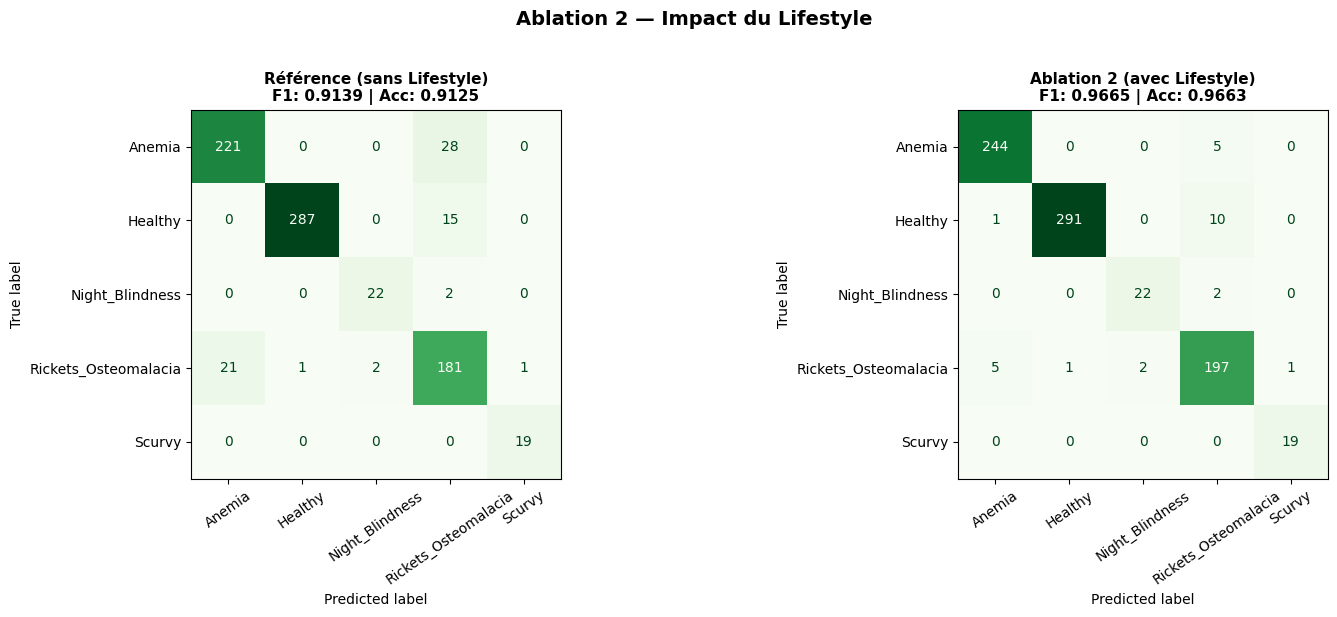

In [15]:
# Comparaison visuelle : Référence vs Avec Lifestyle 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, res, titre in zip(
    axes,
    [res_reference, res_avec_lifestyle],
    ["Référence (sans Lifestyle)", "Ablation 2 (avec Lifestyle)"]
):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=res['le'].classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(
        f"{titre}\nF1: {res['f1']:.4f} | Acc: {res['accuracy']:.4f}",
        fontsize=11, fontweight='bold'
    )
    ax.tick_params(axis='x', rotation=35)

plt.suptitle("Ablation 2 — Impact du Lifestyle", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation2_lifestyle.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Bilan chiffré Ablation 2 
diff_f1_life  = res_avec_lifestyle['f1']       - res_reference['f1']
diff_acc_life = res_avec_lifestyle['accuracy'] - res_reference['accuracy']
diff_cv_life  = res_avec_lifestyle['cv_mean']  - res_reference['cv_mean']

print(f"\n Impact du Lifestyle :")
print(f"   ΔF1  = {diff_f1_life:+.4f}  {' Lifestyle aide' if diff_f1_life > 0.01 else '⚠️  Neutre' if abs(diff_f1_life) <= 0.01 else '❌ Lifestyle nuit (bruit)'}")
print(f"   ΔAcc = {diff_acc_life:+.4f}")
print(f"   ΔCV  = {diff_cv_life:+.4f}")

print("\n CONCLUSION ABLATION 2 :")
if diff_f1_life > 0.01:
    print("   Les variables lifestyle AMÉLIORENT le modèle.")
    print("   → La décision de les supprimer en v2 était INCORRECTE.")
elif abs(diff_f1_life) <= 0.01:
    print("   Les variables lifestyle n'ont pas d'impact significatif.")
    print("   → La décision de les supprimer en v2 était CORRECTE (économie de complexité).")
else:
    print("   Les variables lifestyle DÉGRADENT le modèle (bruit ajouté).")
    print("   → La décision de les supprimer en v2 était EXCELLENTE.")


 Impact du Lifestyle :
   ΔF1  = +0.0526   Lifestyle aide
   ΔAcc = +0.0538
   ΔCV  = +0.0420

 CONCLUSION ABLATION 2 :
   Les variables lifestyle AMÉLIORENT le modèle.
   → La décision de les supprimer en v2 était INCORRECTE.


---
###  Conclusion Section 3 — Ablation 2 : Impact du Lifestyle

| Configuration | CV F1 | Test F1 | Test Acc |
|---------------|-------|---------|----------|
| Référence (sans Lifestyle) | 0.9232 ± 0.0108 | 0.9139 | 0.9125 |
| Avec Lifestyle | 0.9651 ± 0.0082 | 0.9665 | 0.9663 |
| **Différence** | +0.0420 | +0.0526 | +0.0538 |

**Interprétation pour le rapport :**
- Référence : 181 bien classés, 21 confondus avec Anemia
- Avec Lifestyle : 197 bien classés, seulement 5 confondus avec Anemia
- Le lifestyle (exposition soleil, latitude, BMI...) aide énormément à distinguer Rickets d'Anemia : ce qui est cliniquement logique : Rickets est causé par manque de vitamine D, lié à l'exposition solaire et la latitude géographique.

---
## Section 4 — Ablation 3 : Impact des Marqueurs Biologiques

### Ce qu'on teste ici
On **supprime les marqueurs biologiques** (taux sanguins + % RDA) et on garde uniquement les symptômes.
C'est le test le plus important : les bio sont censés être le cœur du modèle.

```
Référence   : Bio ✅ + Symptômes
Ablation 3  : Bio ❌ + Symptômes  ← on enlève les marqueurs bio
               ↑
        seul changement
```

### Question à répondre
> Les marqueurs biologiques sont-ils vraiment le moteur du modèle ?
> Que se passe-t-il si on prédit uniquement à partir des symptômes visibles ?

In [29]:
# Ablation 3 : Symptômes uniquement (sans Bio)
X_symp, y_symp, le_symp, cols_symp = preparer_donnees(df, FEATURES_SYMPTOMES)

print(f"Features utilisées : {len(cols_symp)} (référence = {len(cols_ref)})")
print(f"Colonnes : {cols_symp}")

res_sans_bio = evaluer_configuration(
    X_symp, y_symp,
    avec_smote=True,
    avec_normalisation=True,
    label="Sans Bio (Symptômes uniquement + SMOTE + Scaler)"
)
res_sans_bio['le'] = le_symp

Features utilisées : 8 (référence = 20)
Colonnes : ['has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin']

  Configuration : Sans Bio (Symptômes uniquement + SMOTE + Scaler)
  CV F1 moyen  : 0.7481 ± 0.0138
  Test F1      : 0.7403
  Test Accuracy: 0.7300


In [28]:
# Rapport détaillé — Sans Bio 
print("Rapport détaillé par classe — Sans Marqueurs Biologiques :")
print(classification_report(
    res_sans_bio['y_test'],
    res_sans_bio['y_pred'],
    target_names=le_symp.classes_
))

Rapport détaillé par classe — Sans Marqueurs Biologiques :
                      precision    recall  f1-score   support

              Anemia       0.80      0.61      0.69       249
             Healthy       0.93      0.81      0.87       302
     Night_Blindness       0.27      0.62      0.38        24
Rickets_Osteomalacia       0.60      0.80      0.68       206
              Scurvy       0.47      0.37      0.41        19

            accuracy                           0.73       800
           macro avg       0.61      0.64      0.61       800
        weighted avg       0.77      0.73      0.74       800



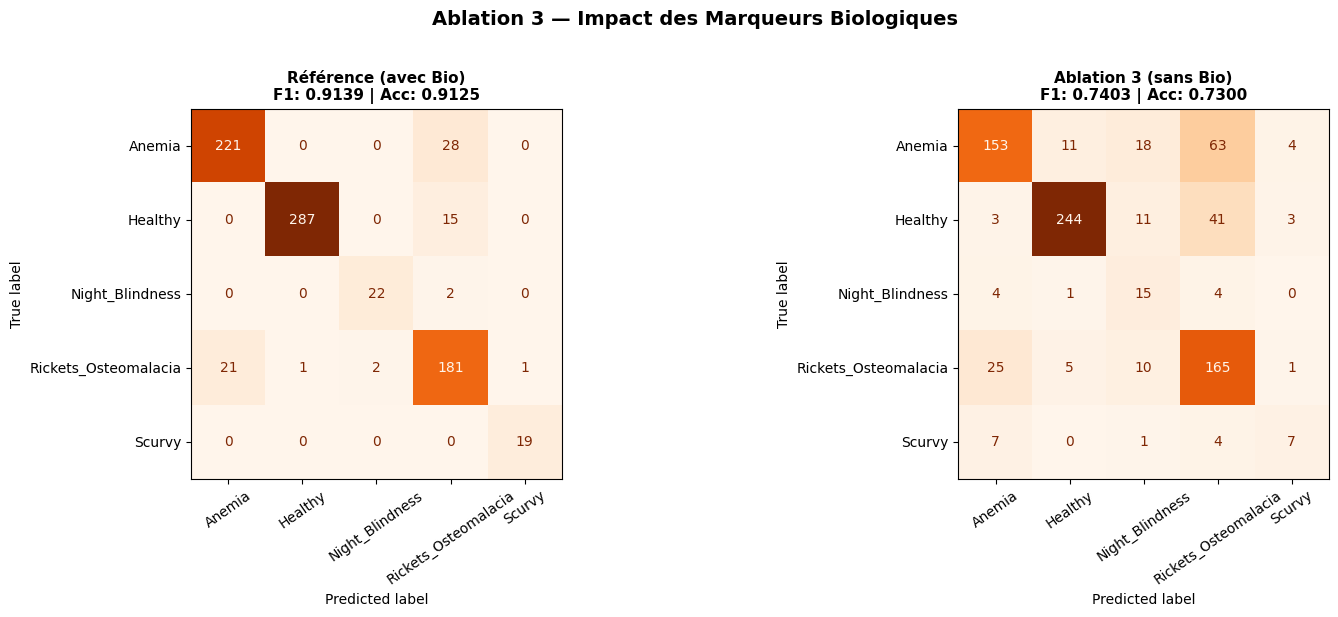

In [19]:
# Comparaison visuelle : Référence vs Sans Bio 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, res, titre in zip(
    axes,
    [res_reference, res_sans_bio],
    ["Référence (avec Bio)", "Ablation 3 (sans Bio)"]
):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=res['le'].classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(
        f"{titre}\nF1: {res['f1']:.4f} | Acc: {res['accuracy']:.4f}",
        fontsize=11, fontweight='bold'
    )
    ax.tick_params(axis='x', rotation=35)

plt.suptitle("Ablation 3 — Impact des Marqueurs Biologiques", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation3_bio.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Bilan chiffré Ablation 3 
diff_f1_bio  = res_sans_bio['f1']       - res_reference['f1']
diff_acc_bio = res_sans_bio['accuracy'] - res_reference['accuracy']
diff_cv_bio  = res_sans_bio['cv_mean']  - res_reference['cv_mean']

print(f"\n Impact des Marqueurs Biologiques :")
print(f"   ΔF1  = {diff_f1_bio:+.4f}")
print(f"   ΔAcc = {diff_acc_bio:+.4f}")
print(f"   ΔCV  = {diff_cv_bio:+.4f}")

print("\n CONCLUSION ABLATION 3 :")
if diff_f1_bio < -0.10:
    print("   Les marqueurs biologiques sont ESSENTIELS : leur suppression dégrade fortement le modèle.")
    print("   → Le modèle repose principalement sur les données sanguines, pas sur les symptômes visuels.")
    print("   → Cela valide l'approche médicale : un diagnostic fiable nécessite des analyses biologiques.")
elif diff_f1_bio < -0.03:
    print("   Les marqueurs biologiques ont un impact modéré.")
    print("   → Les symptômes apportent une part d'information non négligeable.")
else:
    print("   Surprise : les symptômes seuls suffisent presque autant que Bio + Symptômes.")
    print("   → À investiguer : possible corrélation forte entre symptômes et maladies.")


 Impact des Marqueurs Biologiques :
   ΔF1  = -0.1736
   ΔAcc = -0.1825
   ΔCV  = -0.1750

 CONCLUSION ABLATION 3 :
   Les marqueurs biologiques sont ESSENTIELS : leur suppression dégrade fortement le modèle.
   → Le modèle repose principalement sur les données sanguines, pas sur les symptômes visuels.
   → Cela valide l'approche médicale : un diagnostic fiable nécessite des analyses biologiques.


---
###  Conclusion Section 4 — Ablation 3 : Impact des Marqueurs Biologiques

| Configuration | CV F1 | Test F1 | Test Acc |
|---------------|-------|---------|----------|
| Référence (avec Bio) | 0.9232 ± 0.0108 | 0.9139 | 0.9125 |
| Sans Bio (Symptômes seuls) | 0.7481 ± 0.0138 | 0.7403 | 0.7300 |
| **Différence** | -0.1750 | -0.1736 | -0.1825 |

**Interprétation pour le rapport :**
- C'est le résultat le plus important de toute l'ablation study. Les symptômes seuls donnent 73% d'accuracy un resultats bien insuffisant pour un diagnostic médical fiable. Ça valide complètement l'approche clinique : un médecin ne peut pas diagnostiquer une carence vitaminique juste sur les symptômes, il faut les analyses sanguines.
---
## Section 5 — Ablation 4 : Impact de la Normalisation

### Ce qu'on teste ici
On **désactive le StandardScaler** (normalisation) pour voir son impact.
Sans normalisation, les features avec de grandes valeurs (ex: hemoglobin = 14.5 g/dL)
dominent les features binaires (ex: has_fatigue = 0 ou 1).

```
Référence   : Bio + Symptômes + SMOTE + Scaler ✅
Ablation 4  : Bio + Symptômes + SMOTE + Scaler ❌
                                          ↑
                                   seul changement
```

### Question à répondre
> La normalisation est-elle indispensable pour le Random Forest ?
> (Note : le RF est théoriquement invariant à l'échelle, contrairement à SVM et KNN)

In [21]:
#  Ablation 4 : Sans Normalisation 
res_sans_scaler = evaluer_configuration(
    X_ref, y_ref,
    avec_smote=True,
    avec_normalisation=False,
    label="Sans Normalisation (Bio + Symptômes + SMOTE)"
)
res_sans_scaler['le'] = le_ref


  Configuration : Sans Normalisation (Bio + Symptômes + SMOTE)
  CV F1 moyen  : 0.9244 ± 0.0099
  Test F1      : 0.9224
  Test Accuracy: 0.9213


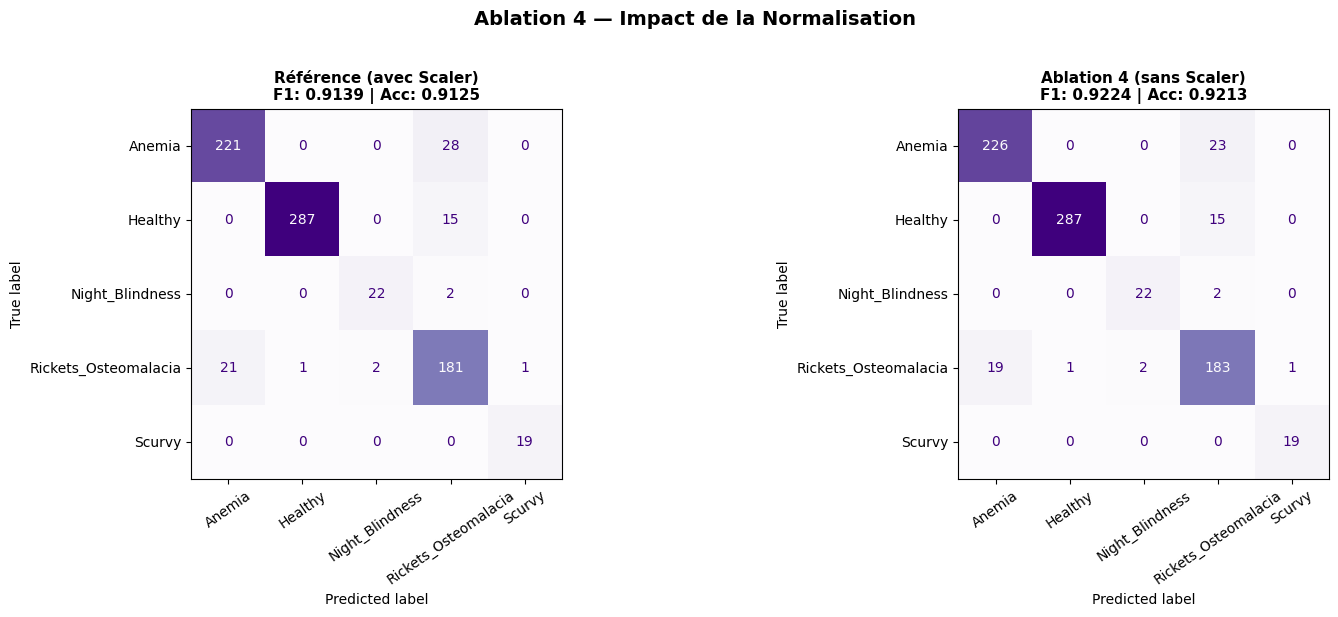

In [22]:
# Comparaison visuelle : Référence vs Sans Scaler 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, res, titre in zip(
    axes,
    [res_reference, res_sans_scaler],
    ["Référence (avec Scaler)", "Ablation 4 (sans Scaler)"]
):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le_ref.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(
        f"{titre}\nF1: {res['f1']:.4f} | Acc: {res['accuracy']:.4f}",
        fontsize=11, fontweight='bold'
    )
    ax.tick_params(axis='x', rotation=35)

plt.suptitle("Ablation 4 — Impact de la Normalisation", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation4_scaler.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Bilan chiffré Ablation 4 
diff_f1_sc  = res_sans_scaler['f1']       - res_reference['f1']
diff_acc_sc = res_sans_scaler['accuracy'] - res_reference['accuracy']
diff_cv_sc  = res_sans_scaler['cv_mean']  - res_reference['cv_mean']

print(f"\n Impact de la Normalisation :")
print(f"   ΔF1  = {diff_f1_sc:+.4f}")
print(f"   ΔAcc = {diff_acc_sc:+.4f}")
print(f"   ΔCV  = {diff_cv_sc:+.4f}")

print("\n CONCLUSION ABLATION 4 :")
if abs(diff_f1_sc) <= 0.01:
    print("   La normalisation a peu d'impact sur le Random Forest.")
    print("   → Attendu : le RF est invariant à l'échelle des features (pas de distance euclidienne).")
    print("   → Par contre, elle reste INDISPENSABLE si on utilise SVM ou KNN (cf. v1/v2/v3).")
elif diff_f1_sc < -0.02:
    print("   La normalisation améliore quand même le Random Forest.")
    print("   → Peut-être via l'interaction avec SMOTE (génération de points synthétiques).")
else:
    print("   Résultat inattendu : la normalisation dégrade légèrement les performances.")
    print("   → Peut être dû à la nature binaire des features symptômes (0/1).")


 Impact de la Normalisation :
   ΔF1  = +0.0085
   ΔAcc = +0.0088
   ΔCV  = +0.0013

 CONCLUSION ABLATION 4 :
   La normalisation a peu d'impact sur le Random Forest.
   → Attendu : le RF est invariant à l'échelle des features (pas de distance euclidienne).
   → Par contre, elle reste INDISPENSABLE si on utilise SVM ou KNN (cf. v1/v2/v3).


---
###  Conclusion Section 5 — Ablation 4 : Impact de la Normalisation

| Configuration | CV F1 | Test F1 | Test Acc |
|---------------|-------|---------|----------|
| Référence (avec Scaler) | 0.9232 ± 0.0108 | 0.9139 | 0.9125 |
| Sans Scaler | 0.9244 ± 0.0099 | 0.9224 | 0.9213 |
| **Différence** | +0.0013 | +0.0085 | +0.0088 |

**Note théorique pour le rapport :**
Le Random Forest n'utilise pas de distances euclidiennes → il est théoriquement insensible à l'échelle.
La normalisation reste critique pour **SVM** et **KNN** (utilisés en v1, v2, v3).

---
## Section 6 — Tableau Récapitulatif de Toutes les Ablations

Synthèse de **toutes les conclusions** pour le rapport final.

In [24]:
# ── Tableau récapitulatif complet ────────────────────────
recap = pd.DataFrame([
    {
        'Section'       : 'Référence',
        'Configuration' : 'Bio + Symptômes + SMOTE + Scaler',
        'Ce qui change' : '— (baseline)',
        'CV F1'         : res_reference['cv_mean'],
        'Test F1'       : res_reference['f1'],
        'Test Acc'      : res_reference['accuracy'],
        'ΔF1 vs Réf'    : 0.0
    },
    {
        'Section'       : 'Ablation 1',
        'Configuration' : 'Bio + Symptômes + Scaler',
        'Ce qui change' : 'SMOTE retiré',
        'CV F1'         : res_sans_smote['cv_mean'],
        'Test F1'       : res_sans_smote['f1'],
        'Test Acc'      : res_sans_smote['accuracy'],
        'ΔF1 vs Réf'    : res_sans_smote['f1'] - res_reference['f1']
    },
    {
        'Section'       : 'Ablation 2',
        'Configuration' : 'Bio + Symptômes + Lifestyle + SMOTE + Scaler',
        'Ce qui change' : 'Lifestyle ajouté',
        'CV F1'         : res_avec_lifestyle['cv_mean'],
        'Test F1'       : res_avec_lifestyle['f1'],
        'Test Acc'      : res_avec_lifestyle['accuracy'],
        'ΔF1 vs Réf'    : res_avec_lifestyle['f1'] - res_reference['f1']
    },
    {
        'Section'       : 'Ablation 3',
        'Configuration' : 'Symptômes uniquement + SMOTE + Scaler',
        'Ce qui change' : 'Marqueurs Bio retirés',
        'CV F1'         : res_sans_bio['cv_mean'],
        'Test F1'       : res_sans_bio['f1'],
        'Test Acc'      : res_sans_bio['accuracy'],
        'ΔF1 vs Réf'    : res_sans_bio['f1'] - res_reference['f1']
    },
    {
        'Section'       : 'Ablation 4',
        'Configuration' : 'Bio + Symptômes + SMOTE',
        'Ce qui change' : 'Normalisation retirée',
        'CV F1'         : res_sans_scaler['cv_mean'],
        'Test F1'       : res_sans_scaler['f1'],
        'Test Acc'      : res_sans_scaler['accuracy'],
        'ΔF1 vs Réf'    : res_sans_scaler['f1'] - res_reference['f1']
    }
])

print("TABLEAU RÉCAPITULATIF — ABLATION STUDY COMPLÈTE")
print("=" * 80)
print(recap[['Section','Ce qui change','CV F1','Test F1','Test Acc','ΔF1 vs Réf']].round(4).to_string(index=False))

TABLEAU RÉCAPITULATIF — ABLATION STUDY COMPLÈTE
   Section         Ce qui change  CV F1  Test F1  Test Acc  ΔF1 vs Réf
 Référence          — (baseline) 0.9232   0.9139    0.9125      0.0000
Ablation 1          SMOTE retiré 0.9230   0.9222    0.9212      0.0083
Ablation 2      Lifestyle ajouté 0.9651   0.9665    0.9662      0.0526
Ablation 3 Marqueurs Bio retirés 0.7481   0.7403    0.7300     -0.1736
Ablation 4 Normalisation retirée 0.9244   0.9224    0.9212      0.0085


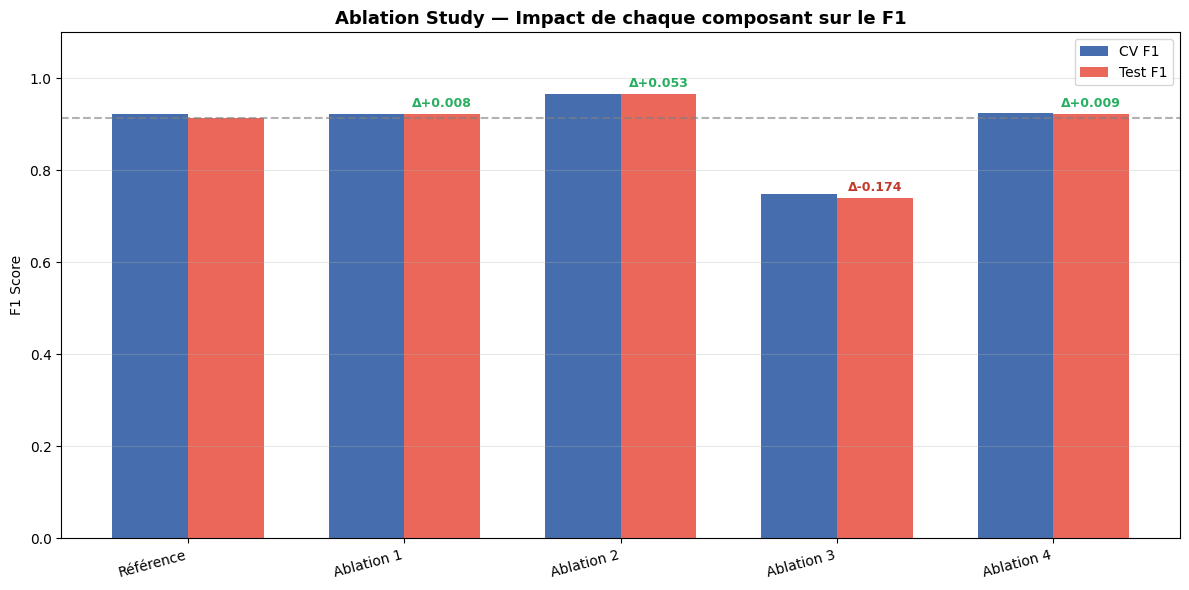


✅ Graphique récapitulatif sauvegardé : ablation_recap_final.png


In [25]:
# ── Graphique récapitulatif ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

labels   = recap['Section'].tolist()
f1_vals  = recap['Test F1'].tolist()
cv_vals  = recap['CV F1'].tolist()
deltas   = recap['ΔF1 vs Réf'].tolist()

x = np.arange(len(labels))
w = 0.35

bars1 = ax.bar(x - w/2, cv_vals,  w, label='CV F1',   color='#2655A0', alpha=0.85)
bars2 = ax.bar(x + w/2, f1_vals,  w, label='Test F1', color='#e74c3c', alpha=0.85)

# Annotations ΔF1
for i, (bar, delta) in enumerate(zip(bars2, deltas)):
    if i > 0:  # pas pour la référence
        color = '#27ae60' if delta >= 0 else '#c0392b'
        ax.annotate(
            f'Δ{delta:+.3f}',
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, 5), textcoords='offset points',
            ha='center', fontsize=9, color=color, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Ablation Study — Impact de chaque composant sur le F1',
             fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=res_reference['f1'], color='gray', linestyle='--', alpha=0.6, label='F1 Référence')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_recap_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Graphique récapitulatif sauvegardé : ablation_recap_final.png")

In [35]:
# Conclusions automatiques pour le rapport 

print("\n" + "=" * 65)
print("  CONCLUSIONS FINALES — À INTÉGRER DANS LE RAPPORT")
print("=" * 65)

composants = [
    ("SMOTE",          res_sans_smote['f1']       - res_reference['f1']),
    ("Lifestyle",      res_avec_lifestyle['f1']   - res_reference['f1']),
    ("Marqueurs Bio",  res_sans_bio['f1']         - res_reference['f1']),
    ("Normalisation",  res_sans_scaler['f1']      - res_reference['f1']),
]

composants_tries = sorted(composants, key=lambda x: abs(x[1]), reverse=True)

print("\nClassement des composants par importance (impact sur F1) :")
for rang, (nom, delta) in enumerate(composants_tries, 1):
    if delta < -0.03:
        sens = 'indispensable'
    elif delta < -0.01:
        sens = 'utile'
    elif abs(delta) <= 0.01:
        sens = 'neutre'
    else:
        sens = 'bénéfique'
    print(f"  #{rang} {nom:<20} ΔF1 = {delta:+.4f}  → {sens}")

print("\n" + "-" * 65)
print("Méthode : Random Forest, RepeatedStratifiedKFold (5×3), SMOTE pipeline")
print(f"Référence F1 : {res_reference['f1']:.4f}")


  CONCLUSIONS FINALES — À INTÉGRER DANS LE RAPPORT

Classement des composants par importance (impact sur F1) :
  #1 Marqueurs Bio        ΔF1 = -0.1736  → indispensable
  #2 Lifestyle            ΔF1 = +0.0526  → bénéfique
  #3 Normalisation        ΔF1 = +0.0085  → neutre
  #4 SMOTE                ΔF1 = +0.0083  → neutre

-----------------------------------------------------------------
Méthode : Random Forest, RepeatedStratifiedKFold (5×3), SMOTE pipeline
Référence F1 : 0.9139


---
##  Conclusions Globales — Ablation Study Complète

### Résumé des 4 ablations

| Ablation | Composant testé | ΔF1 | Verdict |
|----------|----------------|-----|--------|
| 1 | SMOTE retiré | +0.0083 | Neutre globalement — mais crucial pour Scurvy et Night_Blindness |
| 2 | Lifestyle ajouté | +0.0526 | Bénéfique — la suppression en V2 était une erreur |
| 3 | Marqueurs Bio retirés | -0.1736 | Indispensable — c'est le cœur du modèle |
| 4 | Normalisation retirée | +0.0085 | Neutre — RF insensible à l'échelle comme prévu |



- Les marqueurs biologiques sont indispensables (ΔF1 = -0.1736)
Sans les analyses sanguines, le modèle chute de 91% à 74%. Un diagnostic de carence vitaminique ne peut pas reposer uniquement sur les symptômes.
- Le Lifestyle apporte de l'information réelle (ΔF1 = +0.0526)
C'est la surprise du notebook. La décision de V2 de supprimer ces variables était incorrecte — sun_exposure et latitude_region aident énormément à distinguer Rickets des autres carences.
- SMOTE et Normalisation sont neutres sur le F1 global
Mais le SMOTE reste important pour les classes rares (Scurvy, Night_Blindness) — le score global ne le montre pas, mais les matrices de confusion oui.

---